# EE 446 TinyML - Lab 8 Part II: Tiny Ensemble Learning

This notebook demonstrates a complete TinyML ensemble-learning pipeline for IMU-based human activity classification. The code is already implemented. Your task is to run the notebook, understand the pipeline, and answer the discussion questions at the end.

The pipeline uses the `mHealth_subject6.log` dataset and builds three model branches using different input representations:

- Raw IMU windows
- Standard-scaled IMU windows
- Min-max-scaled IMU windows

Each branch trains an autoencoder, uses the encoder output as a latent feature vector, and trains a classifier. The three classifier softmax outputs are then concatenated and passed into a small stacked meta-classifier. The notebook then compresses selected models using pruning, quantization-aware training (QAT), and full integer TFLite conversion for TinyML deployment.

This notebook is designed for the local `tinyml-arduino` environment.

Recommended way to start JupyterLab:

```bash
source ~/ai/projects/tinyml-arduino/bin/activate
jupyter lab
```

Required files in the same folder as this notebook:

- `mHealth_subject6.log`
- Optional for the final validation section: `imu_500_rows.csv`

You do not need to fill in missing code. Run the cells in order and use the results to answer the discussion questions.


## Discussion Questions

Submit your answers for Part II in the same PDF used for Lab 8 Part I.

### Question 1: Model architecture and ensemble flow

Draw a complete diagram of the full ensemble pipeline. Your diagram should include enough detail for someone to reconstruct the model architecture from your drawing.

Include the following details:

- The input window size and number of input neurons. In this notebook, each input window has 100 time steps and 6 IMU features, so the flattened input dimension is 600.
- The three input branches: raw input, standard-scaled input, and min-max-scaled input.
- The encoder architecture in each branch, including the number of hidden layers, number of neurons in each layer, and activation function used in each layer.
- The classifier architecture in each branch, including the number of input neurons, hidden-layer neurons, output neurons, and activation functions.
- The number of models used in the ensemble and how they are connected.
- The size of each branch output and how the three outputs are concatenated before being passed into the stacked meta-classifier.
- The stacked meta-classifier architecture, including input size, hidden layer size, output size, and activation functions.

### Question 2: Pruning and QAT methodology

Explain how this notebook compresses the models for TinyML deployment.

In your answer, describe:

- How pruning is applied and what sparsity schedule is used.
- Why the pruning wrappers are stripped before QAT.
- How QAT is applied after pruning.
- Why the notebook uses an additional mask-enforcement step during and after QAT instead of using only a simple pruning-then-QAT pipeline.
- How the final model is converted to an int8 TFLite model and why representative data is needed.
- How pruning and int8 quantization help when deploying to a resource-constrained device such as the Arduino Nano 33 BLE Sense.

### Question 3: Arduino deployment and real-world behavior

Deploy the quantized model using the provided Arduino sketch for this lab. Place the Arduino Nano 33 BLE Sense flat on a stable surface, open the serial monitor, and observe the predicted activity labels.

In your answer, include:

- A screenshot of the serial monitor output.
- A short explanation of whether the output is acceptable for the resting board condition.
- Any issues you observe, such as unstable predictions, unexpected labels, sensor noise, scaling mismatch, or mismatch between the training data and the real board orientation.
- One or two practical changes that could improve deployment reliability.

### Question 4: Deployment Behavior on the Arduino

After deploying the ensemble model on the Arduino Nano 33 BLE Sense / Sense Rev2, did you observe any unexpected prediction behavior? For example, did the model repeatedly predict the same class even when the board was moved differently?

Briefly explain why this may happen. In your answer, discuss possible causes such as differences between the original training dataset and the live Arduino sensor data, sensor placement, axis orientation, unit conversion, feature scaling, or mismatch between the motion patterns used during training and testing.


## 1. Environment check

This cell verifies that the notebook is running inside the intended Python environment and that the required libraries are available. It does not install or uninstall packages.


In [1]:
import os
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import sys
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

try:
    import tensorflow_model_optimization as tfmot
except ImportError as exc:
    raise ImportError(
        "tensorflow_model_optimization is not installed in this environment. "
        "Activate tinyml-arduino and install tensorflow-model-optimization before running this notebook."
    ) from exc

print("Python executable:", sys.executable)
print("Python version:", platform.python_version())
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-05-25 16:22:00.608748: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-25 16:22:00.611615: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-25 16:22:00.641298: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-25 16:22:00.641334: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-25 16:22:00.641355: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

Python executable: /home/sn340/ai/projects/tinyml-arduino/bin/python
Python version: 3.11.15
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Load and prepare the mHealth dataset

The mHealth subject 6 log file contains multiple sensor channels and an activity label. This lab uses six IMU features: three accelerometer channels and three gyroscope channels. The label column is converted from 1-based labels to 0-based labels for TensorFlow training.


In [2]:
DATA_FILE = Path("mHealth_subject6.log")

if not DATA_FILE.exists():
    raise FileNotFoundError(
        "mHealth_subject6.log was not found. Place the file in the same folder as this notebook and rerun this cell."
    )

sensor_features = ["Accel_X", "Accel_Y", "Accel_Z", "Gyro_X", "Gyro_Y", "Gyro_Z"]
sensor_cols = {
    5: "Accel_X", 6: "Accel_Y", 7: "Accel_Z",
    8: "Gyro_X", 9: "Gyro_Y", 10: "Gyro_Z"
}

label_map = {
    0: "Standing still",
    1: "Sitting and relaxing",
    2: "Lying down",
    3: "Walking",
    4: "Climbing stairs",
    5: "Waist bends forward",
    6: "Frontal elevation of arms",
    7: "Knees bending (crouching)",
    8: "Cycling",
    9: "Jogging",
    10: "Running",
    11: "Jump front and back",
}

raw_df = pd.read_csv(DATA_FILE, sep="\t", header=None)
raw_df = raw_df[raw_df[23] > 0].copy()
raw_df.rename(columns=sensor_cols, inplace=True)

sensor_df = raw_df[sensor_features].copy()
sensor_df["Label"] = raw_df[23].to_numpy(dtype=int) - 1

print("Dataset shape:", sensor_df.shape)
print("Class labels:", sorted(sensor_df["Label"].unique()))
print("\nOriginal feature statistics:")
display(sensor_df[sensor_features].describe())


Dataset shape: (32205, 7)
Class labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

Original feature statistics:


,Accel_X,Accel_Y,Accel_Z,Gyro_X,Gyro_Y,Gyro_Z
count,32205.000000,32205.000000,32205.000000,32205.000000,32205.000000,32205.000000
mean,3.268805,-9.153526,0.700608,-0.020571,-0.520382,-0.299817
std,4.253270,5.397648,6.433731,0.325434,0.571107,0.542112
min,-22.091000,-19.571000,-19.363000,-0.977740,-1.611600,-1.206300
25%,1.284000,-10.420000,-1.359900,-0.235620,-0.863040,-0.662080
50%,2.427500,-9.583100,1.509900,-0.027829,-0.731710,-0.479370
75%,4.725200,-8.039700,2.456600,0.192950,-0.452160,0.341850
max,20.003000,20.909000,24.599000,1.463800,1.557200,1.326100


## 3. Create raw, standard-scaled, and min-max-scaled datasets

The ensemble uses three versions of the same IMU signal. This creates diversity across the branches without changing the underlying activity labels.


In [3]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X_features = sensor_df[sensor_features].to_numpy(dtype=np.float32)
y_labels = sensor_df["Label"].to_numpy(dtype=int)

std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(X_features).astype(np.float32)

minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X_features).astype(np.float32)

sensor_df_raw = pd.DataFrame(X_features, columns=sensor_features)
sensor_df_raw["Label"] = y_labels

sensor_df_std = pd.DataFrame(X_std, columns=sensor_features)
sensor_df_std["Label"] = y_labels

sensor_df_minmax = pd.DataFrame(X_minmax, columns=sensor_features)
sensor_df_minmax["Label"] = y_labels

print("Standard-scaled feature statistics:")
display(sensor_df_std[sensor_features].describe())

print("Min-max-scaled feature statistics:")
display(sensor_df_minmax[sensor_features].describe())


Standard-scaled feature statistics:


,Accel_X,Accel_Y,Accel_Z,Gyro_X,Gyro_Y,Gyro_Z
count,32205.000000,3.220500e+04,32205.000000,3.220500e+04,3.220500e+04,3.220500e+04
mean,0.000000,-1.061316e-07,0.000000,-1.516166e-08,1.895208e-09,7.580830e-09
std,1.000015,1.000015e+00,1.000015,1.000015e+00,1.000015e+00,1.000015e+00
min,-5.962517,-1.930032e+00,-3.118551,-2.941250e+00,-1.910735e+00,-1.672159e+00
25%,-0.466661,-2.346382e-01,-0.320271,-6.608158e-01,-5.999974e-01,-6.682549e-01
50%,-0.197805,-7.958682e-02,0.125791,-2.230210e-02,-3.700372e-01,-3.312160e-01
75%,0.342423,2.063571e-01,0.272940,6.561219e-01,1.194581e-01,1.183661e+00
max,3.934491,5.569647e+00,3.714605,4.561272e+00,3.637870e+00,2.999273e+00


Min-max-scaled feature statistics:


,Accel_X,Accel_Y,Accel_Z,Gyro_X,Gyro_Y,Gyro_Z
count,32205.000000,32205.000000,32205.000000,32205.000000,32205.000000,32205.000000
mean,0.602457,0.257349,0.456385,0.392035,0.344363,0.357954
std,0.101042,0.133341,0.146348,0.133291,0.180228,0.214070
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.555305,0.226062,0.409515,0.303956,0.236228,0.214903
50%,0.582470,0.246737,0.474794,0.389062,0.277673,0.287052
75%,0.637055,0.284864,0.496329,0.479488,0.365892,0.611337
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 4. Convert the time series into flattened windows

Each sample is a 100-time-step window with 6 sensor features. The model input dimension is therefore:

`100 time steps x 6 features = 600 input neurons`

The split is done within each class to preserve the temporal structure of each activity segment.


In [4]:
WINDOW_SIZE = 100
STRIDE = 1
NUM_CLASSES = 12


def create_windows(X_seq, label, window_size=WINDOW_SIZE, stride=STRIDE):
    windows = []
    labels = []
    for start in range(0, len(X_seq) - window_size + 1, stride):
        window = X_seq[start:start + window_size].reshape(-1)
        windows.append(window)
        labels.append(label)
    return windows, labels


def window_and_split(df_scaled, train_fraction=0.7):
    X_train_windows, X_test_windows = [], []
    y_train_labels, y_test_labels = [], []

    for label in sorted(df_scaled["Label"].unique()):
        df_class = df_scaled[df_scaled["Label"] == label]
        X_class = df_class[sensor_features].to_numpy(dtype=np.float32)
        split_idx = int(train_fraction * len(X_class))

        train_windows, train_labels = create_windows(X_class[:split_idx], label)
        test_windows, test_labels = create_windows(X_class[split_idx:], label)

        X_train_windows.extend(train_windows)
        y_train_labels.extend(train_labels)
        X_test_windows.extend(test_windows)
        y_test_labels.extend(test_labels)

    return (
        np.asarray(X_train_windows, dtype=np.float32),
        np.asarray(X_test_windows, dtype=np.float32),
        np.asarray(y_train_labels, dtype=int),
        np.asarray(y_test_labels, dtype=int),
    )

X_train_raw, X_test_raw, y_train_raw, y_test_raw = window_and_split(sensor_df_raw)
X_train_std, X_test_std, y_train_std, y_test_std = window_and_split(sensor_df_std)
X_train_minmax, X_test_minmax, y_train_minmax, y_test_minmax = window_and_split(sensor_df_minmax)

print("Raw input:", X_train_raw.shape, X_test_raw.shape)
print("Standard-scaled input:", X_train_std.shape, X_test_std.shape)
print("Min-max-scaled input:", X_train_minmax.shape, X_test_minmax.shape)


Raw input: (21350, 600) (8479, 600)
Standard-scaled input: (21350, 600) (8479, 600)
Min-max-scaled input: (21350, 600) (8479, 600)


## 5. Visualize the three input representations with t-SNE

This visualization helps compare how the raw, standard-scaled, and min-max-scaled windows are distributed before training the autoencoders. To keep the notebook practical on a local machine, the plot uses a stratified subset of test windows.


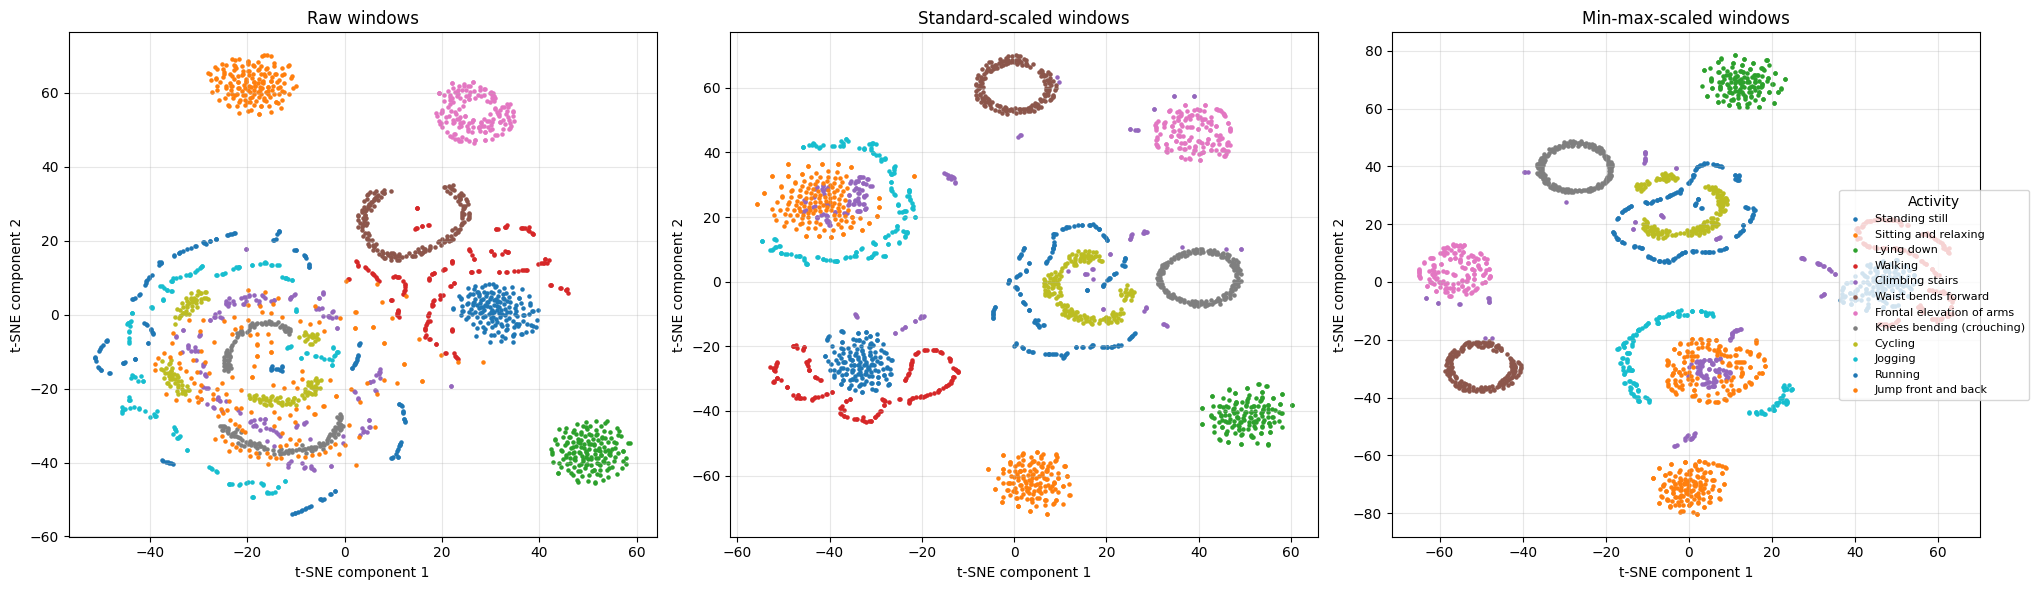

In [5]:
from sklearn.manifold import TSNE

TSNE_MAX_SAMPLES = 2000


def stratified_subset(X, y, max_samples=TSNE_MAX_SAMPLES, random_state=42):
    rng = np.random.default_rng(random_state)
    labels = np.unique(y)
    per_class = max(1, max_samples // len(labels))
    chosen = []

    for label in labels:
        idx = np.where(y == label)[0]
        sample_size = min(per_class, len(idx))
        chosen.extend(rng.choice(idx, size=sample_size, replace=False))

    chosen = np.asarray(chosen)
    rng.shuffle(chosen)
    return X[chosen], y[chosen]


def compute_tsne(X, random_state=42):
    kwargs = dict(n_components=2, perplexity=30, learning_rate=300, random_state=random_state)
    try:
        return TSNE(max_iter=1000, **kwargs).fit_transform(X)
    except TypeError:
        return TSNE(n_iter=1000, **kwargs).fit_transform(X)


def run_tsne_and_plot(X_test, y_test, title, ax):
    X_sub, y_sub = stratified_subset(X_test, y_test)
    X_tsne = compute_tsne(X_sub)

    for label in sorted(np.unique(y_sub)):
        idx = y_sub == label
        ax.scatter(X_tsne[idx, 0], X_tsne[idx, 1], s=5, label=label_map[label])

    ax.set_title(title)
    ax.set_xlabel("t-SNE component 1")
    ax.set_ylabel("t-SNE component 2")
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
run_tsne_and_plot(X_test_raw, y_test_raw, "Raw windows", axes[0])
run_tsne_and_plot(X_test_std, y_test_std, "Standard-scaled windows", axes[1])
run_tsne_and_plot(X_test_minmax, y_test_minmax, "Min-max-scaled windows", axes[2])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Activity", loc="center right", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()


## 6. Train one autoencoder for each input representation

Each autoencoder reconstructs its own input representation. The encoder part is then used as a compact feature extractor.

Encoder architecture for each branch:

`600 input neurons -> Dense(64, ReLU) -> Dense(32, linear)`

Decoder architecture for each branch:

`32 latent neurons -> Dense(64, ReLU) -> Dense(600, linear)`


In [6]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam

AUTOENCODER_EPOCHS = 50
BATCH_SIZE = 256
LATENT_DIM = 32


def build_autoencoder(input_dim, latent_dim=LATENT_DIM):
    input_layer = Input(shape=(input_dim,), name="input_window")
    encoded = Dense(64, activation="relu", name="encoder_dense_64")(input_layer)
    latent = Dense(latent_dim, activation="linear", name="latent_32")(encoded)
    decoded = Dense(64, activation="relu", name="decoder_dense_64")(latent)
    reconstructed = Dense(input_dim, activation="linear", name="reconstruction")(decoded)

    autoencoder = Model(inputs=input_layer, outputs=reconstructed, name="autoencoder")
    encoder = Model(inputs=input_layer, outputs=latent, name="encoder")
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss="mse")
    return autoencoder, encoder


def train_autoencoder_branch(X_train, branch_name):
    input_dim = X_train.shape[1]
    autoencoder, encoder = build_autoencoder(input_dim)
    print(f"Training autoencoder for {branch_name} input")
    autoencoder.fit(
        X_train,
        X_train,
        epochs=AUTOENCODER_EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        verbose=1,
    )
    return autoencoder, encoder

models = {
    "raw": train_autoencoder_branch(X_train_raw, "raw"),
    "std": train_autoencoder_branch(X_train_std, "standard-scaled"),
    "minmax": train_autoencoder_branch(X_train_minmax, "min-max-scaled"),
}


2026-05-25 16:23:56.632204: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-25 16:23:56.633719: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Training autoencoder for raw input
Epoch 1/50
84/84 [==============================] - 1s 5ms/step - loss: 14.5996
Epoch 2/50
84/84 [==============================] - 0s 4ms/step - loss: 8.3054
Epoch 3/50
84/84 [==============================] - 0s 5ms/step - loss: 7.4104
Epoch 4/50
84/84 [==============================] - 0s 4ms/step - loss: 6.7631
Epoch 5/50
84/84 [==============================] - 0s 4ms/step - loss: 6.3473
Epoch 6/50
84/84 [==============================] - 0s 4ms/step - loss: 6.0377
Epoch 7/50
84/84 [==============================] - 0s 3ms/step - loss: 5.7941
Epoch 8/50
84/84 [==============================] - 0s 4ms/step - loss: 5.5938
Epoch 9/50
84/84 [==============================] - 0s 4ms/step - loss: 5.4314
Epoch 10/50
84/84 [==============================] - 0s 3ms/step - loss: 5.2938
Epoch 11/50
84/84 [==============================] - 0s 3ms/step - loss: 5.1892
Epoch 12/50
84/84 [==============================] - 0s 4ms/step - loss: 5.0983
Epoch 13/50
8

## 7. Visualize encoder latent spaces

The encoder maps each 600-dimensional input window to a 32-dimensional latent representation. The t-SNE plots below visualize these latent spaces.


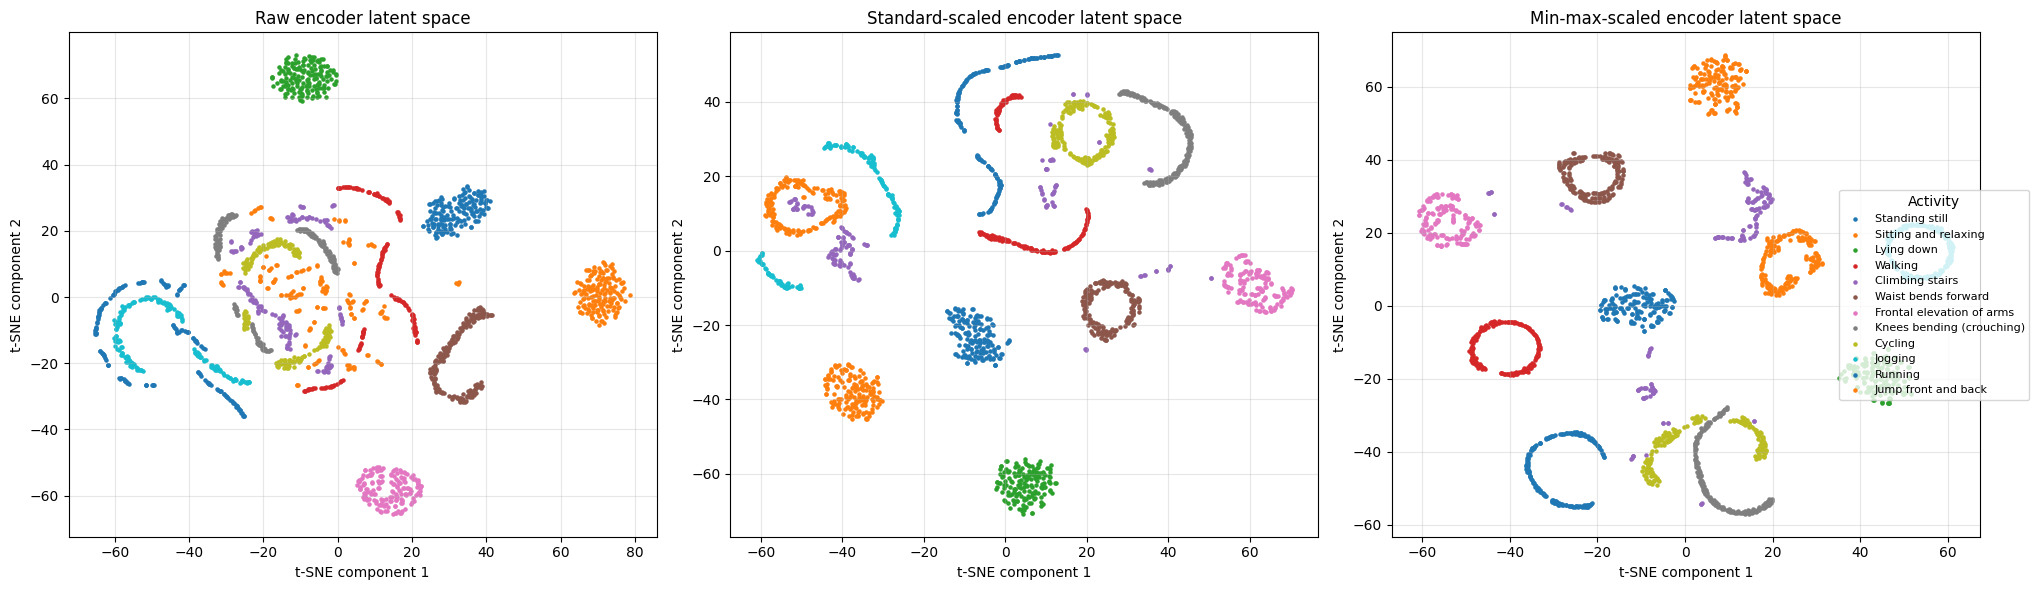

In [7]:
def plot_latent_tsne(encoder, X_test, y_test, title, ax):
    X_sub, y_sub = stratified_subset(X_test, y_test)
    latent = encoder.predict(X_sub, verbose=0)
    latent_tsne = compute_tsne(latent)

    for label in sorted(np.unique(y_sub)):
        idx = y_sub == label
        ax.scatter(latent_tsne[idx, 0], latent_tsne[idx, 1], s=5, label=label_map[label])

    ax.set_title(title)
    ax.set_xlabel("t-SNE component 1")
    ax.set_ylabel("t-SNE component 2")
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
plot_latent_tsne(models["raw"][1], X_test_raw, y_test_raw, "Raw encoder latent space", axes[0])
plot_latent_tsne(models["std"][1], X_test_std, y_test_std, "Standard-scaled encoder latent space", axes[1])
plot_latent_tsne(models["minmax"][1], X_test_minmax, y_test_minmax, "Min-max-scaled encoder latent space", axes[2])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Activity", loc="center right", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()


## 8. Train one classifier on each latent representation

Each classifier receives a 32-dimensional encoder output and predicts one of 12 activity classes.

Classifier architecture for each branch:

`32 latent input neurons -> Dense(20, ReLU) -> Dense(12, Softmax)`


In [8]:
from tensorflow.keras.utils import to_categorical

CLASSIFIER_EPOCHS = 50

y_train_raw_cat = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test_raw_cat = to_categorical(y_test_raw, num_classes=NUM_CLASSES)
y_train_std_cat = to_categorical(y_train_std, num_classes=NUM_CLASSES)
y_test_std_cat = to_categorical(y_test_std, num_classes=NUM_CLASSES)
y_train_minmax_cat = to_categorical(y_train_minmax, num_classes=NUM_CLASSES)
y_test_minmax_cat = to_categorical(y_test_minmax, num_classes=NUM_CLASSES)

latent_train_raw = models["raw"][1].predict(X_train_raw, verbose=0)
latent_test_raw = models["raw"][1].predict(X_test_raw, verbose=0)
latent_train_std = models["std"][1].predict(X_train_std, verbose=0)
latent_test_std = models["std"][1].predict(X_test_std, verbose=0)
latent_train_minmax = models["minmax"][1].predict(X_train_minmax, verbose=0)
latent_test_minmax = models["minmax"][1].predict(X_test_minmax, verbose=0)


def build_classifier(input_dim, num_classes=NUM_CLASSES):
    model = Sequential([
        Input(shape=(input_dim,), name="latent_input"),
        Dense(20, activation="relu", name="classifier_dense_20"),
        Dense(num_classes, activation="softmax", name="activity_softmax"),
    ], name="latent_classifier")
    model.compile(optimizer=Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

clf_raw = build_classifier(latent_train_raw.shape[1])
clf_std = build_classifier(latent_train_std.shape[1])
clf_minmax = build_classifier(latent_train_minmax.shape[1])

print("Training classifier for raw branch")
clf_raw.fit(latent_train_raw, y_train_raw_cat, epochs=CLASSIFIER_EPOCHS, batch_size=BATCH_SIZE, verbose=1)

print("Training classifier for standard-scaled branch")
clf_std.fit(latent_train_std, y_train_std_cat, epochs=CLASSIFIER_EPOCHS, batch_size=BATCH_SIZE, verbose=1)

print("Training classifier for min-max-scaled branch")
clf_minmax.fit(latent_train_minmax, y_train_minmax_cat, epochs=CLASSIFIER_EPOCHS, batch_size=BATCH_SIZE, verbose=1)


Training classifier for raw branch
Epoch 1/50
84/84 [==============================] - 0s 1ms/step - loss: 8.7752 - accuracy: 0.1554
Epoch 2/50
84/84 [==============================] - 0s 1ms/step - loss: 2.7492 - accuracy: 0.3389
Epoch 3/50
84/84 [==============================] - 0s 1ms/step - loss: 1.9023 - accuracy: 0.4791
Epoch 4/50
84/84 [==============================] - 0s 1ms/step - loss: 1.6167 - accuracy: 0.4810
Epoch 5/50
84/84 [==============================] - 0s 1ms/step - loss: 1.3982 - accuracy: 0.4595
Epoch 6/50
84/84 [==============================] - 0s 2ms/step - loss: 1.1977 - accuracy: 0.5264
Epoch 7/50
84/84 [==============================] - 0s 1ms/step - loss: 1.0234 - accuracy: 0.5822
Epoch 8/50
84/84 [==============================] - 0s 1ms/step - loss: 0.8992 - accuracy: 0.6593
Epoch 9/50
84/84 [==============================] - 0s 1ms/step - loss: 0.8082 - accuracy: 0.6754
Epoch 10/50
84/84 [==============================] - 0s 1ms/step - loss: 0.7252 - a

## 9. Evaluate the three branch classifiers

The branch classifiers are evaluated separately before constructing the stacked ensemble.



Classification report: raw branch
                           precision    recall  f1-score   support

           Standing still       1.00      1.00      1.00       823
     Sitting and relaxing       1.00      1.00      1.00       823
               Lying down       1.00      1.00      1.00       823
                  Walking       1.00      1.00      1.00       823
          Climbing stairs       0.97      0.95      0.96       823
      Waist bends forward       1.00      0.99      0.99       562
Frontal elevation of arms       0.99      1.00      1.00       531
Knees bending (crouching)       0.97      0.99      0.98       593
                  Cycling       0.95      0.99      0.97       823
                  Jogging       0.99      0.99      0.99       823
                  Running       0.99      0.99      0.99       823
      Jump front and back       0.96      0.82      0.88       209

                 accuracy                           0.99      8479
                macro avg

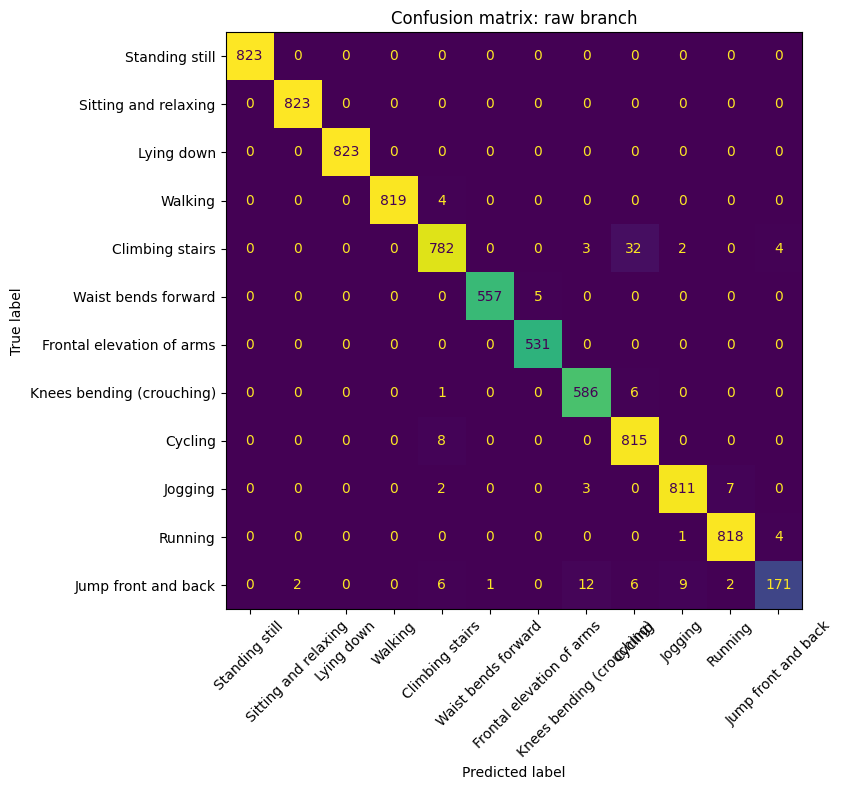


Classification report: standard-scaled branch
                           precision    recall  f1-score   support

           Standing still       1.00      1.00      1.00       823
     Sitting and relaxing       1.00      1.00      1.00       823
               Lying down       1.00      1.00      1.00       823
                  Walking       1.00      1.00      1.00       823
          Climbing stairs       0.99      0.93      0.96       823
      Waist bends forward       0.98      1.00      0.99       562
Frontal elevation of arms       1.00      1.00      1.00       531
Knees bending (crouching)       0.98      1.00      0.99       593
                  Cycling       0.96      1.00      0.98       823
                  Jogging       1.00      1.00      1.00       823
                  Running       1.00      1.00      1.00       823
      Jump front and back       0.99      0.96      0.97       209

                 accuracy                           0.99      8479
             

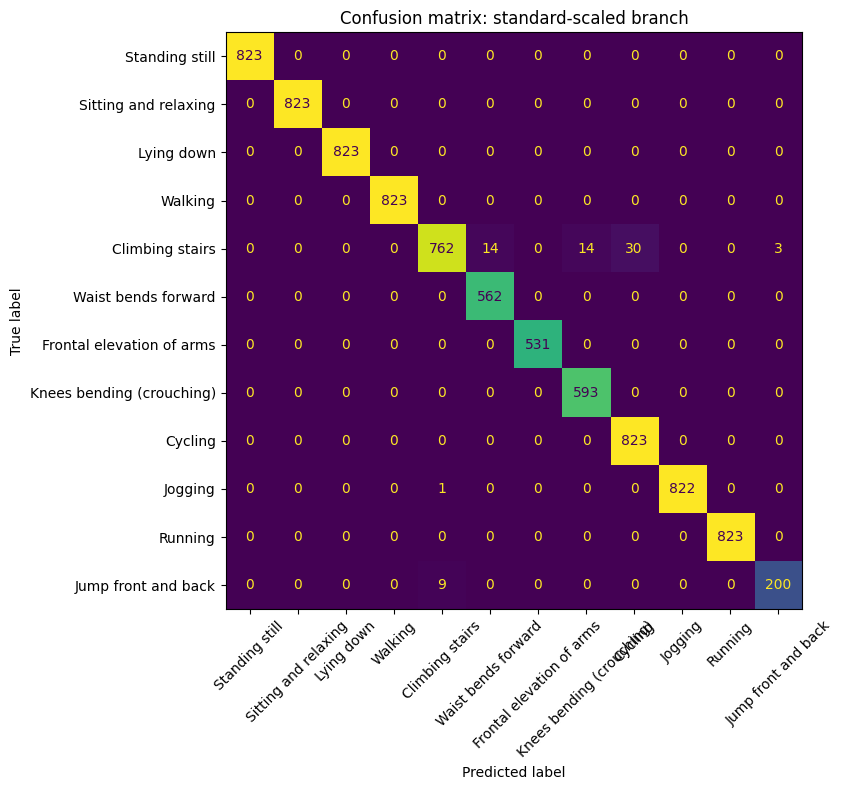


Classification report: min-max-scaled branch
                           precision    recall  f1-score   support

           Standing still       1.00      1.00      1.00       823
     Sitting and relaxing       1.00      1.00      1.00       823
               Lying down       1.00      1.00      1.00       823
                  Walking       0.97      1.00      0.99       823
          Climbing stairs       0.98      0.83      0.90       823
      Waist bends forward       0.99      1.00      0.99       562
Frontal elevation of arms       1.00      1.00      1.00       531
Knees bending (crouching)       0.95      0.99      0.97       593
                  Cycling       0.99      0.97      0.98       823
                  Jogging       0.99      1.00      0.99       823
                  Running       1.00      1.00      1.00       823
      Jump front and back       0.69      0.94      0.79       209

                 accuracy                           0.98      8479
              

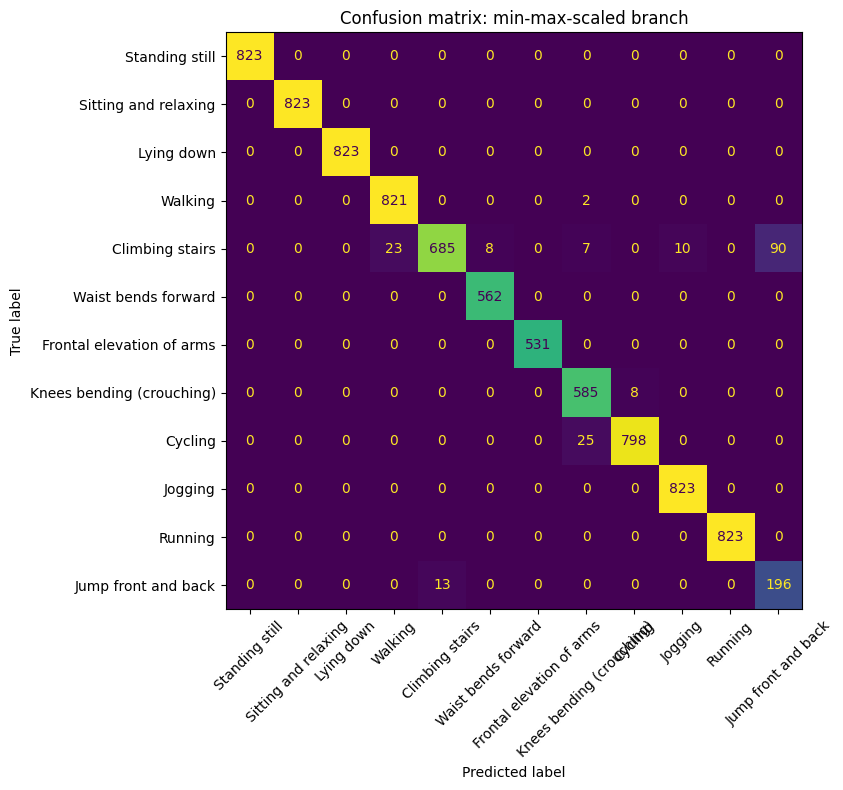

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


def evaluate_classifier(model, X_test, y_test_true, title):
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    target_names = [label_map[i] for i in range(NUM_CLASSES)]

    print(f"\nClassification report: {title}")
    print(classification_report(y_test_true, y_pred, target_names=target_names, zero_division=0))

    cm = confusion_matrix(y_test_true, y_pred, labels=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=ax, xticks_rotation=45, values_format="d", colorbar=False)
    ax.set_title(f"Confusion matrix: {title}")
    plt.tight_layout()
    plt.show()


evaluate_classifier(clf_raw, latent_test_raw, y_test_raw, "raw branch")
evaluate_classifier(clf_std, latent_test_std, y_test_std, "standard-scaled branch")
evaluate_classifier(clf_minmax, latent_test_minmax, y_test_minmax, "min-max-scaled branch")


## 10. Build the stacked ensemble

The three branch classifiers each output a 12-dimensional softmax vector. These outputs are concatenated into a 36-dimensional vector:

`12 raw probabilities + 12 standard-scaled probabilities + 12 min-max-scaled probabilities = 36 ensemble inputs`

The stacked meta-classifier then maps the 36-dimensional ensemble input to the final 12-class prediction.

Meta-classifier architecture:

`36 input neurons -> Dense(24, ReLU) -> Dense(12, Softmax)`


Epoch 1/50
84/84 [==============================] - 0s 2ms/step - loss: 2.1117 - accuracy: 0.5136
Epoch 2/50
84/84 [==============================] - 0s 1ms/step - loss: 1.1195 - accuracy: 0.9707
Epoch 3/50
84/84 [==============================] - 0s 1ms/step - loss: 0.3886 - accuracy: 0.9977
Epoch 4/50
84/84 [==============================] - 0s 1ms/step - loss: 0.1410 - accuracy: 0.9998
Epoch 5/50
84/84 [==============================] - 0s 1ms/step - loss: 0.0656 - accuracy: 1.0000
Epoch 6/50
84/84 [==============================] - 0s 1ms/step - loss: 0.0376 - accuracy: 1.0000
Epoch 7/50
84/84 [==============================] - 0s 2ms/step - loss: 0.0241 - accuracy: 1.0000
Epoch 8/50
84/84 [==============================] - 0s 2ms/step - loss: 0.0167 - accuracy: 1.0000
Epoch 9/50
84/84 [==============================] - 0s 1ms/step - loss: 0.0123 - accuracy: 1.0000
Epoch 10/50
84/84 [==============================] - 0s 1ms/step - loss: 0.0095 - accuracy: 1.0000
Epoch 11/50
84/84 [

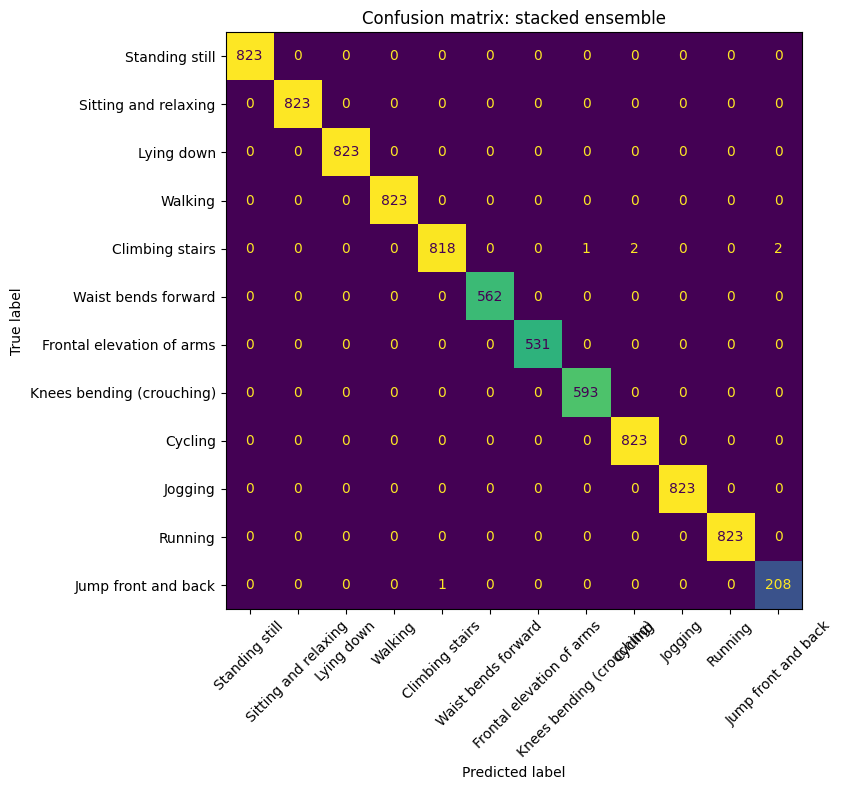

In [10]:
train_logits_raw = clf_raw.predict(latent_train_raw, verbose=0)
test_logits_raw = clf_raw.predict(latent_test_raw, verbose=0)

train_logits_std = clf_std.predict(latent_train_std, verbose=0)
test_logits_std = clf_std.predict(latent_test_std, verbose=0)

train_logits_minmax = clf_minmax.predict(latent_train_minmax, verbose=0)
test_logits_minmax = clf_minmax.predict(latent_test_minmax, verbose=0)

X_train_ensemble = np.hstack([train_logits_raw, train_logits_std, train_logits_minmax]).astype(np.float32)
X_test_ensemble = np.hstack([test_logits_raw, test_logits_std, test_logits_minmax]).astype(np.float32)

y_train_ensemble_cat = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test_ensemble_cat = to_categorical(y_test_raw, num_classes=NUM_CLASSES)

meta_clf = Sequential([
    Input(shape=(36,), name="ensemble_input"),
    Dense(24, activation="relu", name="meta_dense_24"),
    Dense(NUM_CLASSES, activation="softmax", name="meta_softmax"),
], name="stacked_meta_classifier")

meta_clf.compile(optimizer=Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
meta_clf.fit(X_train_ensemble, y_train_ensemble_cat, epochs=CLASSIFIER_EPOCHS, batch_size=BATCH_SIZE, verbose=1)

evaluate_classifier(meta_clf, X_test_ensemble, y_test_raw, "stacked ensemble")


## 11. Convert the trained models to baseline TFLite models

This section converts the trained encoder, branch classifier, and meta-classifier models to regular TFLite models and reports their file sizes. These are not yet the pruned QAT int8 models.


In [11]:
def convert_and_save_tflite(model, name):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()

    filename = Path(f"{name}.tflite")
    filename.write_bytes(tflite_model)

    size_kb = filename.stat().st_size / 1024
    print(f"{name}: {size_kb:.2f} KB")

convert_and_save_tflite(models["raw"][1], "encoder_raw")
convert_and_save_tflite(clf_raw, "clf_raw")
convert_and_save_tflite(models["std"][1], "encoder_std")
convert_and_save_tflite(clf_std, "clf_std")
convert_and_save_tflite(models["minmax"][1], "encoder_minmax")
convert_and_save_tflite(clf_minmax, "clf_minmax")
convert_and_save_tflite(meta_clf, "stacked_meta_clf")


INFO:tensorflow:Assets written to: /tmp/tmps8ja5o85/assets


INFO:tensorflow:Assets written to: /tmp/tmps8ja5o85/assets


encoder_raw: 159.88 KB


2026-05-25 16:26:29.190733: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-25 16:26:29.190787: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-25 16:26:29.191934: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmps8ja5o85
2026-05-25 16:26:29.192269: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-25 16:26:29.192278: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmps8ja5o85
2026-05-25 16:26:29.194144: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-05-25 16:26:29.194377: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-25 16:26:29.206589: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmps8ja5o85
2026-05

INFO:tensorflow:Assets written to: /tmp/tmpgtp1m575/assets


...

2026-05-25 16:26:30.199202: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-25 16:26:30.199246: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-25 16:26:30.199374: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmphptp8dd4
2026-05-25 16:26:30.200200: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-25 16:26:30.200214: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmphptp8dd4
2026-05-25 16:26:30.202218: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-25 16:26:30.225883: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmphptp8dd4
2026-05-25 16:26:30.231401: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 32027 m

INFO:tensorflow:Assets written to: /tmp/tmp3eh2osr3/assets


INFO:tensorflow:Assets written to: /tmp/tmp3eh2osr3/assets


stacked_meta_clf: 6.50 KB


2026-05-25 16:26:30.521838: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-25 16:26:30.521880: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-25 16:26:30.522009: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp3eh2osr3
2026-05-25 16:26:30.522969: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-25 16:26:30.522984: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp3eh2osr3
2026-05-25 16:26:30.524974: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-25 16:26:30.546215: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp3eh2osr3
2026-05-25 16:26:30.551491: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 29481 m

## 12. Create flattened encoder-classifier pipelines

For deployment, each branch can be represented as a single model that maps the 600-dimensional input window directly to a 12-class softmax output.

Each flattened branch has this structure:

`600 input neurons -> Dense(64, ReLU) -> Dense(32, linear) -> Dense(20, ReLU) -> Dense(12, Softmax)`


In [12]:
def combine_encoder_and_classifier(encoder, classifier, name):
    combined = Sequential(name=name)
    combined.add(Input(shape=(encoder.input_shape[1],), name="window_input"))

    for layer in encoder.layers[1:]:
        combined.add(layer)

    for layer in classifier.layers:
        combined.add(layer)

    combined.compile(optimizer=Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
    return combined

flattened_raw = combine_encoder_and_classifier(models["raw"][1], clf_raw, "encoder_clf_raw_flat")
flattened_std = combine_encoder_and_classifier(models["std"][1], clf_std, "encoder_clf_std_flat")
flattened_minmax = combine_encoder_and_classifier(models["minmax"][1], clf_minmax, "encoder_clf_minmax_flat")

flattened_raw.summary()


Model: "encoder_clf_raw_flat"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 encoder_dense_64 (Dense)    (None, 64)                38464     
                                                                 
 latent_32 (Dense)           (None, 32)                2080      
                                                                 
 classifier_dense_20 (Dense  (None, 20)                660       
 )                                                               
                                                                 
 activity_softmax (Dense)    (None, 12)                252       
                                                                 
Total params: 41456 (161.94 KB)
Trainable params: 41456 (161.94 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 13. Pruning, QAT, and int8 TFLite export

This section applies a deployment-oriented compression pipeline:

1. Prune the model using a polynomial sparsity schedule.
2. Strip the pruning wrappers to create a regular Keras model with sparse weights.
3. Apply QAT to simulate quantization effects during fine-tuning.
4. Reapply pruning masks during QAT so previously pruned weights remain zero.
5. Convert the QAT model to a fully int8 TFLite model using representative data.
6. Evaluate the exported TFLite model.


In [13]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning,
)
from tensorflow_model_optimization.quantization.keras import quantize_model, quantize_scope
from tensorflow_model_optimization.python.core.quantization.keras.quantize_wrapper import QuantizeWrapper

PRUNE_EPOCHS = 5
QAT_EPOCHS = 5
PRUNE_END_STEP = 500
REPRESENTATIVE_SAMPLES = 200


def train_and_prune(model, X_train, y_train):
    pruning_schedule = PolynomialDecay(
        initial_sparsity=0.10,
        final_sparsity=0.80,
        begin_step=0,
        end_step=PRUNE_END_STEP,
    )

    pruned_model = prune_low_magnitude(model, pruning_schedule=pruning_schedule)
    pruned_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    pruned_model.fit(
        X_train,
        y_train,
        epochs=PRUNE_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[UpdatePruningStep()],
        verbose=1,
    )
    return pruned_model


def extract_dense_weight_masks(model):
    masks = []
    for layer in model.layers:
        if isinstance(layer, Dense):
            weights = layer.get_weights()
            if weights:
                layer_masks = [(w != 0).astype(np.float32) for w in weights]
                masks.append((layer.name, [w.copy() for w in weights], layer_masks))
    return masks


class MaskEnforcerCallback(tf.keras.callbacks.Callback):
    def __init__(self, masks):
        super().__init__()
        self.masks = masks

    def on_train_batch_end(self, batch, logs=None):
        self.apply_masks()

    def on_epoch_end(self, epoch, logs=None):
        self.apply_masks()

    def apply_masks(self):
        for layer in self.model.layers:
            if not isinstance(layer, QuantizeWrapper):
                continue

            weights = layer.get_weights()
            if len(weights) < 2:
                continue

            for original_name, original_weights, masks in self.masks:
                if len(original_weights) < 2:
                    continue
                if weights[0].shape == original_weights[0].shape and weights[1].shape == original_weights[1].shape:
                    updated_weights = [weights[0] * masks[0], weights[1] * masks[1]] + weights[2:]
                    layer.set_weights(updated_weights)
                    break


def make_representative_data_gen(X_subset, max_samples=REPRESENTATIVE_SAMPLES):
    count = min(len(X_subset), max_samples)
    indices = np.linspace(0, len(X_subset) - 1, count, dtype=int)

    def generator():
        for i in indices:
            yield [X_subset[i:i + 1].astype(np.float32)]

    return generator


def compute_model_sparsity(model):
    total_weights = 0
    total_zeros = 0
    print("\nLayer-wise sparsity:")

    for layer in model.layers:
        weights = layer.get_weights()
        if not weights:
            continue

        kernel = weights[0]
        if kernel.ndim < 2:
            continue

        zeros = np.sum(kernel == 0)
        size = np.prod(kernel.shape)
        total_weights += size
        total_zeros += zeros
        print(f"{layer.name:30s}: {100.0 * zeros / size:6.2f}% sparse ({zeros}/{size})")

    total_sparsity = 100.0 * total_zeros / total_weights if total_weights else 0.0
    print(f"Overall sparsity: {total_sparsity:.2f}% ({total_zeros}/{total_weights})")
    return total_sparsity


def evaluate_tflite_model(tflite_model_path, X_test, y_test):
    interpreter = tf.lite.Interpreter(model_path=str(tflite_model_path))
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    input_index = input_details[0]["index"]
    output_index = output_details[0]["index"]
    input_scale, input_zero_point = input_details[0]["quantization"]

    y_pred = []
    for i in range(len(X_test)):
        input_data = X_test[i:i + 1].astype(np.float32)
        if input_details[0]["dtype"] == np.int8:
            input_data = np.round(input_data / input_scale + input_zero_point).astype(np.int8)

        interpreter.set_tensor(input_index, input_data)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_index)
        y_pred.append(int(np.argmax(output_data)))

    accuracy = float(np.mean(np.asarray(y_pred) == y_test))
    print("\nTFLite classification report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("TFLite confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"TFLite accuracy: {accuracy:.4f}")
    return accuracy


def prune_qat_export(model, X_train, y_train, X_test, y_test, name):
    print(f"\nCompression pipeline for {name}")

    pruned_model = train_and_prune(model, X_train, y_train)
    stripped_model = strip_pruning(pruned_model)
    dense_masks = extract_dense_weight_masks(stripped_model)

    with quantize_scope():
        qat_model = quantize_model(stripped_model)

    qat_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    mask_callback = MaskEnforcerCallback(dense_masks)

    print("Training QAT model with pruning-mask enforcement")
    qat_model.fit(
        X_train,
        y_train,
        epochs=QAT_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[mask_callback],
        verbose=1,
    )
    mask_callback.apply_masks()

    compute_model_sparsity(qat_model)

    converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = make_representative_data_gen(X_train)
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()
    output_path = Path(f"{name}_pruned_qat_int8.tflite")
    output_path.write_bytes(tflite_model)

    print(f"Saved {output_path.name}: {output_path.stat().st_size / 1024:.2f} KB")
    evaluate_tflite_model(output_path, X_test, np.argmax(y_test, axis=1))
    return output_path


## 14. Export compressed branch models and the meta-classifier

The following cells produce four int8 TFLite models:

- Raw encoder-classifier branch
- Standard-scaled encoder-classifier branch
- Min-max-scaled encoder-classifier branch
- Stacked meta-classifier


In [14]:
compressed_model_paths = []

compressed_model_paths.append(
    prune_qat_export(
        flattened_raw,
        X_train_raw,
        y_train_raw_cat,
        X_test_raw,
        y_test_raw_cat,
        "encoder_clf_raw",
    )
)

compressed_model_paths.append(
    prune_qat_export(
        flattened_std,
        X_train_std,
        y_train_std_cat,
        X_test_std,
        y_test_std_cat,
        "encoder_clf_std",
    )
)

compressed_model_paths.append(
    prune_qat_export(
        flattened_minmax,
        X_train_minmax,
        y_train_minmax_cat,
        X_test_minmax,
        y_test_minmax_cat,
        "encoder_clf_minmax",
    )
)

compressed_model_paths.append(
    prune_qat_export(
        meta_clf,
        X_train_ensemble,
        y_train_ensemble_cat,
        X_test_ensemble,
        y_test_ensemble_cat,
        "stacked_meta_clf",
    )
)



Compression pipeline for encoder_clf_raw
Epoch 1/5
84/84 [==============================] - 2s 4ms/step - loss: 0.3179 - accuracy: 0.9343
Epoch 2/5
84/84 [==============================] - 0s 3ms/step - loss: 0.4823 - accuracy: 0.8943
Epoch 3/5
84/84 [==============================] - 0s 2ms/step - loss: 1.1986 - accuracy: 0.7570
Epoch 4/5
84/84 [==============================] - 0s 3ms/step - loss: 2.0365 - accuracy: 0.6481
Epoch 5/5
84/84 [==============================] - 0s 3ms/step - loss: 1.6410 - accuracy: 0.4365
Training QAT model with pruning-mask enforcement
Epoch 1/5
 6/84 [=>............................] - ETA: 0s - loss: 2.1770 - accuracy: 0.1751 WARNING:tensorflow:Callback method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0048s vs `on_train_batch_end` time: 0.0062s). Check your callbacks.


84/84 [==============================] - 1s 9ms/step - loss: 1.6054 - accuracy: 0.3870
Epoch 2/5
84/84 [==============================] - 1s 9ms/step - loss: 1.1301 - accuracy: 0.5963
Epoch 3/5
84/84 [==============================] - 1s 9ms/step - loss: 0.9070 - accuracy: 0.7532
Epoch 4/5
84/84 [==============================] - 1s 8ms/step - loss: 0.8128 - accuracy: 0.7814
Epoch 5/5
84/84 [==============================] - 1s 7ms/step - loss: 0.7448 - accuracy: 0.8003

Layer-wise sparsity:
quant_encoder_dense_64        :  79.44% sparse (30505/38400)
quant_latent_32               :  79.44% sparse (1627/2048)
quant_classifier_dense_20     :  79.38% sparse (508/640)
quant_activity_softmax        :  79.58% sparse (191/240)
Overall sparsity: 79.44% (32831/41328)
INFO:tensorflow:Assets written to: /tmp/tmpqznccgwp/assets


INFO:tensorflow:Assets written to: /tmp/tmpqznccgwp/assets
/home/sn340/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-25 16:26:55.029045: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-25 16:26:55.029088: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-05-25 16:26:55.029215: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpqznccgwp
2026-05-25 16:26:55.032275: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-25 16:26:55.032289: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpqznccgwp
2026-05-25 16:26:55.039819: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
202

Saved encoder_clf_raw_pruned_qat_int8.tflite: 44.55 KB

TFLite classification report:
              precision    recall  f1-score   support

           0       0.60      1.00      0.75       823
           1       1.00      1.00      1.00       823
           2       0.99      1.00      1.00       823
           3       0.85      0.95      0.89       823
           4       0.51      0.84      0.64       823
           5       1.00      1.00      1.00       562
           6       0.00      0.00      0.00       531
           7       0.98      0.46      0.62       593
           8       0.73      0.99      0.84       823
           9       0.98      0.23      0.38       823
          10       0.98      1.00      0.99       823
          11       0.94      0.89      0.92       209

    accuracy                           0.80      8479
   macro avg       0.80      0.78      0.75      8479
weighted avg       0.80      0.80      0.76      8479

TFLite confusion matrix:
[[823   0   0   0   0 

84/84 [==============================] - 1s 9ms/step - loss: 0.4414 - accuracy: 0.8043
Epoch 2/5
84/84 [==============================] - 1s 7ms/step - loss: 0.2436 - accuracy: 0.8674
Epoch 3/5
84/84 [==============================] - 1s 7ms/step - loss: 0.1450 - accuracy: 0.9001
Epoch 4/5
84/84 [==============================] - 1s 7ms/step - loss: 0.1123 - accuracy: 0.9035
Epoch 5/5
84/84 [==============================] - 0s 261us/step - loss: 0.0968 - accuracy: 0.9039

Layer-wise sparsity:
quant_encoder_dense_64        :  79.44% sparse (30505/38400)
quant_latent_32               :  79.44% sparse (1627/2048)
quant_classifier_dense_20     :  79.38% sparse (508/640)
quant_activity_softmax        :  79.58% sparse (191/240)
Overall sparsity: 79.44% (32831/41328)
INFO:tensorflow:Assets written to: /tmp/tmp74g5lewu/assets


...

84/84 [==============================] - 1s 2ms/step - loss: 6.6313e-05 - accuracy: 1.0000
Epoch 2/5
84/84 [==============================] - 0s 1ms/step - loss: 0.0049 - accuracy: 1.0000
Epoch 3/5
84/84 [==============================] - 0s 1ms/step - loss: 0.0927 - accuracy: 0.9772
Epoch 4/5
84/84 [==============================] - 0s 1ms/step - loss: 0.2317 - accuracy: 0.8912
Epoch 5/5
84/84 [==============================] - 0s 1ms/step - loss: 0.2723 - accuracy: 0.8776
Training QAT model with pruning-mask enforcement
Epoch 1/5
 1/84 [..............................] - ETA: 30s - loss: 0.2077 - accuracy: 0.9453WARNING:tensorflow:Callback method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0021s vs `on_train_batch_end` time: 0.0030s). Check your callbacks.


84/84 [==============================] - 1s 4ms/step - loss: 0.2139 - accuracy: 0.9071
Epoch 2/5
84/84 [==============================] - 0s 4ms/step - loss: 0.1673 - accuracy: 0.9136
Epoch 3/5
84/84 [==============================] - 0s 4ms/step - loss: 0.1400 - accuracy: 0.9647
Epoch 4/5
84/84 [==============================] - 0s 4ms/step - loss: 0.1216 - accuracy: 0.9704
Epoch 5/5
84/84 [==============================] - 0s 4ms/step - loss: 0.1082 - accuracy: 0.9711

Layer-wise sparsity:
quant_meta_dense_24           :  79.40% sparse (686/864)
quant_meta_softmax            :  79.51% sparse (229/288)
Overall sparsity: 79.43% (915/1152)
INFO:tensorflow:Assets written to: /tmp/tmp8mp6jebp/assets


INFO:tensorflow:Assets written to: /tmp/tmp8mp6jebp/assets
/home/sn340/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-05-25 16:27:14.115000: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-05-25 16:27:14.115042: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


Saved stacked_meta_clf_pruned_qat_int8.tflite: 3.63 KB

TFLite classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       823
           1       1.00      1.00      1.00       823
           2       0.81      1.00      0.89       823
           3       0.99      1.00      0.99       823
           4       1.00      0.97      0.98       823
           5       1.00      1.00      1.00       562
           6       1.00      1.00      1.00       531
           7       1.00      1.00      1.00       593
           8       0.99      1.00      1.00       823
           9       1.00      1.00      1.00       823
          10       1.00      1.00      1.00       823
          11       0.72      0.06      0.11       209

    accuracy                           0.97      8479
   macro avg       0.96      0.92      0.91      8479
weighted avg       0.97      0.97      0.96      8479

TFLite confusion matrix:
[[823   0   0   0   0 

2026-05-25 16:27:14.115168: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp8mp6jebp
2026-05-25 16:27:14.116843: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-05-25 16:27:14.116857: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp8mp6jebp
2026-05-25 16:27:14.121360: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-05-25 16:27:14.152348: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp8mp6jebp
2026-05-25 16:27:14.161054: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 45886 microseconds.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 15. Report compressed model sizes


In [15]:
print("Compressed int8 TFLite model sizes")
print(f"{'Model':45s} {'Size (KB)':>10s}")
print("-" * 58)

for path in compressed_model_paths:
    path = Path(path)
    if path.exists():
        print(f"{path.name:45s} {path.stat().st_size / 1024:10.2f}")
    else:
        print(f"{path.name:45s} {'missing':>10s}")


Compressed int8 TFLite model sizes
Model                                          Size (KB)
----------------------------------------------------------
encoder_clf_raw_pruned_qat_int8.tflite             44.55
encoder_clf_std_pruned_qat_int8.tflite             44.55
encoder_clf_minmax_pruned_qat_int8.tflite          44.61
stacked_meta_clf_pruned_qat_int8.tflite             3.63


## 16. Convert TFLite files to C arrays for Arduino deployment

The Arduino sketch can include model files as C arrays. This cell uses `xxd`, which is available by default on macOS and Linux.


In [17]:
import subprocess

for path in compressed_model_paths:
    path = Path(path)
    output_cc = path.with_suffix(".cc")
    if path.exists():
        with output_cc.open("w") as f:
            subprocess.run(["xxd", "-i", str(path)], stdout=f, check=True)
        print(f"Created {output_cc.name}")
    else:
        print(f"Skipped {path.name}; file not found")


Created encoder_clf_raw_pruned_qat_int8.cc
Created encoder_clf_std_pruned_qat_int8.cc
Created encoder_clf_minmax_pruned_qat_int8.cc
Created stacked_meta_clf_pruned_qat_int8.cc


## 17. Scaling parameters for Arduino implementation

The Arduino sketch needs the same scaling parameters used during training. Use these printed values when implementing standard scaling and min-max scaling on the board.


In [18]:
print("Standard-scaling parameters")
for feature, mean, std in zip(sensor_features, std_scaler.mean_, np.sqrt(std_scaler.var_)):
    print(f"{feature:8s}: mean = {mean: .6f}, std = {std: .6f}")

print("\nMin-max-scaling parameters")
for feature, min_val, max_val in zip(sensor_features, minmax_scaler.data_min_, minmax_scaler.data_max_):
    print(f"{feature:8s}: min = {min_val: .6f}, max = {max_val: .6f}")


Standard-scaling parameters
Accel_X : mean =  3.268805, std =  4.253204
Accel_Y : mean = -9.153526, std =  5.397565
Accel_Z : mean =  0.700608, std =  6.433631
Gyro_X  : mean = -0.020571, std =  0.325429
Gyro_Y  : mean = -0.520382, std =  0.571098
Gyro_Z  : mean = -0.299817, std =  0.542104

Min-max-scaling parameters
Accel_X : min = -22.091000, max =  20.003000
Accel_Y : min = -19.570999, max =  20.909000
Accel_Z : min = -19.363001, max =  24.599001
Gyro_X  : min = -0.977740, max =  1.463800
Gyro_Y  : min = -1.611600, max =  1.557200
Gyro_Z  : min = -1.206300, max =  1.326100


## 18. Optional recorded-IMU validation

If you recorded a new IMU file named `imu_500_rows.csv`, this section runs the trained Keras models on that file. The expected CSV columns are:

`acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z`

This section is useful for checking whether real board data behaves similarly to the training data. If the CSV file is not present, the cell will skip this validation.


In [19]:
RECORDED_IMU_FILE = Path("imu_500_rows.csv")

if not RECORDED_IMU_FILE.exists():
    print("imu_500_rows.csv was not found. Skipping recorded-IMU validation.")
else:
    df_new = pd.read_csv(RECORDED_IMU_FILE)
    df_new = df_new.rename(columns={
        "acc_x": "Accel_X",
        "acc_y": "Accel_Y",
        "acc_z": "Accel_Z",
        "gyro_x": "Gyro_X",
        "gyro_y": "Gyro_Y",
        "gyro_z": "Gyro_Z",
    })

    missing_columns = [col for col in sensor_features if col not in df_new.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns in imu_500_rows.csv: {missing_columns}")

    X_new_raw_features = df_new[sensor_features].to_numpy(dtype=np.float32)
    X_new_std_features = std_scaler.transform(X_new_raw_features).astype(np.float32)
    X_new_minmax_features = minmax_scaler.transform(X_new_raw_features).astype(np.float32)

    def create_windows_from_array(X, window_size=WINDOW_SIZE, stride=STRIDE):
        return np.asarray(
            [X[start:start + window_size].reshape(-1) for start in range(0, len(X) - window_size + 1, stride)],
            dtype=np.float32,
        )

    X_raw_new = create_windows_from_array(X_new_raw_features)
    X_std_new = create_windows_from_array(X_new_std_features)
    X_minmax_new = create_windows_from_array(X_new_minmax_features)

    if len(X_raw_new) == 0:
        raise ValueError("The recorded IMU file does not contain enough rows to create one full window.")

    logits_raw = flattened_raw.predict(X_raw_new, verbose=0)
    logits_std = flattened_std.predict(X_std_new, verbose=0)
    logits_minmax = flattened_minmax.predict(X_minmax_new, verbose=0)

    pred_raw = np.argmax(logits_raw, axis=1)
    pred_std = np.argmax(logits_std, axis=1)
    pred_minmax = np.argmax(logits_minmax, axis=1)

    X_meta_new = np.hstack([logits_raw, logits_std, logits_minmax]).astype(np.float32)
    meta_logits = meta_clf.predict(X_meta_new, verbose=0)
    pred_meta = np.argmax(meta_logits, axis=1)

    print("Recorded-IMU input windows:")
    print("Raw:", X_raw_new.shape)
    print("Standard scaled:", X_std_new.shape)
    print("Min-max scaled:", X_minmax_new.shape)

    print("\nFirst 10 predicted class IDs")
    print("Raw branch:             ", pred_raw[:10])
    print("Standard-scaled branch: ", pred_std[:10])
    print("Min-max-scaled branch:  ", pred_minmax[:10])
    print("Stacked meta-classifier:", pred_meta[:10])

    print("\nFirst 10 stacked meta-classifier labels")
    print([label_map[int(label)] for label in pred_meta[:10]])


imu_500_rows.csv was not found. Skipping recorded-IMU validation.
